In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Sequential

from tensorflow.keras.optimizers.legacy import Optimizer
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

import pickle
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.regularizers import l2

from time import perf_counter

2025-04-19 05:05:13.225410: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-19 05:05:13.262590: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-19 05:05:13.262748: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-19 05:05:13.263885: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-19 05:05:13.270053: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-19 05:05:13.271428: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
counts = pd.read_csv('/work/counts_pred.csv')

X = pd.read_csv('/work/preprocessed.csv')
X['No Of Withdrawals'] = StandardScaler().fit_transform(counts)
y = pd.read_csv('/work/target.csv')['Total amount Withdrawn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_norm = (y_train - y_train.min()) / (y_train.max() - y_train.min())
y_test_norm = (y_test - y_test.min()) / (y_test.max() - y_test.min())


In [16]:

@keras.utils.register_keras_serializable()
def qd_objective(y_true, y_pred):

    # hyperparameters
    lambda_ = 0.005 # lambda in loss fn
    alpha_ = 0.05  # capturing (1-alpha)% of samples
    soften_ = 75
    n_ = 32
    
    '''Loss_QD-soft, from algorithm 1'''
    y_true = y_true[:,0]
    y_u = y_pred[:,0]
    y_l = y_pred[:,1]

    K_HU = tf.maximum(0.,tf.sign(y_u - y_true))
    K_HL = tf.maximum(0.,tf.sign(y_true - y_l))
    K_H = tf.multiply(K_HU, K_HL)

    K_SU = tf.sigmoid(soften_ * (y_u - y_true))
    K_SL = tf.sigmoid(soften_ * (y_true - y_l))
    K_S = tf.multiply(K_SU, K_SL)

    MPIW_c = tf.reduce_sum(tf.multiply((y_u - y_l),K_H))/tf.reduce_sum(K_H)
    PICP_H = tf.reduce_mean(K_H)
    PICP_S = tf.reduce_mean(K_S)

    Loss_S = MPIW_c + lambda_ * n_ / (alpha_*(1-alpha_)) * tf.maximum(0.,(1-alpha_) - PICP_S)

    return Loss_S

In [32]:

def run_ann(X_train, y_train, validation_split):

    num_features = X_train.shape[1]

    model = Sequential([
        Dense(64, activation='relu', input_shape=(num_features,), kernel_initializer=keras.initializers.RandomNormal(mean=0.0, stddev=0.2),
            kernel_regularizer=l2(1e-2)),
        BatchNormalization(),
        Dense(128, activation='relu', kernel_initializer=keras.initializers.RandomNormal(mean=0.0, stddev=0.2),
            kernel_regularizer=l2(1e-2)),
        Dropout(0.25),
        Dense(128, activation='relu', kernel_initializer=keras.initializers.RandomNormal(mean=0.0, stddev=0.2),
            kernel_regularizer=l2(1e-2)),
        Dropout(0.25),
        BatchNormalization(),
        Dense(2, activation='softplus', kernel_initializer=keras.initializers.RandomNormal(mean=0.0, stddev=0.3),
                    bias_initializer=keras.initializers.Constant(value=[3.,-3.])) # important to init biases to start!
    ])


    opt = AdamW(learning_rate=0.001, weight_decay=0.01)
    model.compile(optimizer=opt, loss=qd_objective, metrics=['mae'])

    history = model.fit(X_train, y_train, epochs=200, batch_size=32, verbose=1, validation_split=validation_split)
    
    return model, history


In [35]:
t1 = perf_counter()
model, history = run_ann(X_train, y_train_norm, validation_split=0.1)
t2 = perf_counter()

print(f'Time taken: {t2-t1:0.1f} seconds')

Epoch 1/200
286/286 [==============================] - 2s 3ms/step - loss: 12.5131 - mae: 0.9382 - val_loss: 10.6608 - val_mae: 0.3109
Epoch 2/200
286/286 [==============================] - 1s 2ms/step - loss: 9.9116 - mae: 0.4975 - val_loss: 8.0213 - val_mae: 0.3694
Epoch 3/200
286/286 [==============================] - 1s 2ms/step - loss: 8.2187 - mae: 0.5051 - val_loss: 6.6658 - val_mae: 0.5087
Epoch 4/200
286/286 [==============================] - 1s 2ms/step - loss: 6.7252 - mae: 0.5466 - val_loss: 5.6186 - val_mae: 0.4966
Epoch 5/200
286/286 [==============================] - 1s 2ms/step - loss: 5.6556 - mae: 0.5089 - val_loss: 4.6745 - val_mae: 0.4117
Epoch 6/200
286/286 [==============================] - 1s 2ms/step - loss: 4.7006 - mae: 0.4688 - val_loss: 4.0217 - val_mae: 0.4306
Epoch 7/200
286/286 [==============================] - 1s 2ms/step - loss: 3.9435 - mae: 0.4501 - val_loss: 3.2717 - val_mae: 0.3476
Epoch 8/200
286/286 [==============================] - 1s 2ms/step 

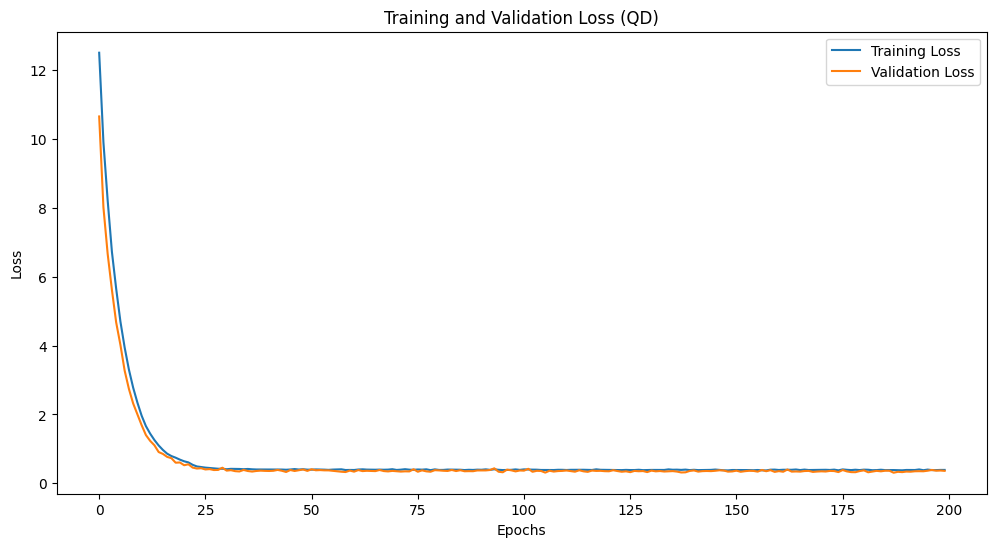

In [36]:
plt.figure(figsize=(12,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss (QD)')
plt.show()

In [37]:

model, history = run_ann(X_train, y_train_norm, validation_split=0.0)

Epoch 1/200
317/317 [==============================] - 2s 2ms/step - loss: 12.3398 - mae: 0.8662
Epoch 2/200
317/317 [==============================] - 1s 2ms/step - loss: 9.7547 - mae: 0.5206
Epoch 3/200
317/317 [==============================] - 1s 2ms/step - loss: 7.9727 - mae: 0.5323
Epoch 4/200
317/317 [==============================] - 1s 3ms/step - loss: 6.6038 - mae: 0.5167
Epoch 5/200
317/317 [==============================] - 1s 3ms/step - loss: 5.5031 - mae: 0.4630
Epoch 6/200
317/317 [==============================] - 1s 3ms/step - loss: 4.5959 - mae: 0.4478
Epoch 7/200
317/317 [==============================] - 1s 3ms/step - loss: 3.7877 - mae: 0.3980
Epoch 8/200
317/317 [==============================] - 1s 3ms/step - loss: 3.1511 - mae: 0.3787
Epoch 9/200
317/317 [==============================] - 1s 3ms/step - loss: 2.6080 - mae: 0.3472
Epoch 10/200
317/317 [==============================] - 1s 3ms/step - loss: 2.1700 - mae: 0.3184
Epoch 11/200
317/317 [================

In [38]:

model.save('qd_amt.keras')
model.save('qd_amt.h5')

with open('qd_amt', 'wb') as file:

    pickle.dump(model, file)

In [39]:
# plot and view some predictions
y_pred_amt = model.predict(X_test, verbose=0)

y_pred_amt_denorm = y_pred_amt * (y_test.max() - y_test.min()) + y_test.min()

ub_amt = y_pred_amt_denorm[:,0].flatten().astype('int')
lb_amt = y_pred_amt_denorm[:,1].flatten().astype('int')
mean_pred_amt = (ub_amt + lb_amt) / 2


In [40]:
below_ub = (ub_amt >= y_test).sum() / len(y_test)
print('Points Below Upper Bound:', below_ub)

below_lb = (y_test <= lb_amt).sum() / len(y_test)
print('Points Below Lower Bound:', below_lb)

Points Below Upper Bound: 0.9573964497041421
Points Below Lower Bound: 0.005128205128205128


In [41]:
def compute_picp(y_lower, y_upper, y_true):
    return np.mean(np.logical_and(y_true >= y_lower, y_true <= y_upper))

def compute_pinrw(y_lower, y_upper, y_true):
    R = np.max(y_true) - np.min(y_true)
    width = np.sqrt(np.mean((y_upper - y_lower) ** 2))
    return width / R

def compute_pinrw(y_lower, y_upper, y_true):
    R = np.max(y_true) - np.min(y_true)
    width = np.sqrt(np.mean((y_upper - y_lower) ** 2))
    return width / R

def cwc_loss_numpy(y_lower, y_upper, y_true, gamma=50, eta=50, mu=0.95):
    picp = compute_picp(y_lower, y_upper, y_true)
    pinrw = compute_pinrw(y_lower, y_upper, y_true)
    penalty = np.exp(eta * (mu - picp))
    cwc = pinrw * (1 + gamma * penalty)
    mpiw = np.mean(y_upper - y_lower)

    return cwc, picp, mpiw, pinrw

In [42]:
cwc, picp, mpiw, pinrw = cwc_loss_numpy(lb_amt, ub_amt, y_test, gamma=50, eta=50, mu=0.95)

outcome = (y_test > lb_amt) & (y_test < ub_amt)

result = pd.DataFrame({'Original': y_test, 'Predicted': mean_pred_amt,
                        'Lower Bound': lb_amt, 'Upper Bound': ub_amt,
                      'Outcome': outcome})

result.to_csv(f'Results_QD_amt.csv', index=False)


In [45]:
print('PICP: ', picp)
print('PINRW: ', pinrw)
print('CWC: ', cwc)
print('MPIW: ', mpiw)

PICP:  0.9522682445759368
PINRW:  0.3017137731999992
CWC:  13.76995341745587
MPIW:  361727.31400394475


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=6c5dcd7e-ee44-459a-9dd6-5c39b2404cb3' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>